# 01 — Tratamento e preparação dos dados

## Projeto: análise e previsão do NPS

**Membros do Grupo:** Amanda Alves, Fabio Costa, Gabriel Victor, Vanessa Partala

**Etapas do CRISP-DM:** compreensão e preparação dos dados  
**Arquivo de entrada:** `data/desafio_nps_fase_1.csv`  
**Arquivo de saída:** `data/processed/nps_tratado.csv`

---

## Contexto

A empresa possui informações sobre clientes, pedidos, entregas, atendimento e
satisfação. Antes da análise exploratória e da modelagem, precisamos verificar se
os dados estão completos, consistentes e adequados ao objetivo do projeto.

Este notebook foi organizado para que outras pessoas consigam acompanhar o
processo, entender as decisões tomadas e reproduzir os resultados.

## Objetivos

- Compreender a estrutura e a unidade de análise da base;
- Verificar valores ausentes, duplicidades e tipos de dados;
- Avaliar a coerência dos valores;
- Investigar possíveis outliers;
- Padronizar nomes e categorias;
- Criar variáveis derivadas úteis para a EDA e o modelo;
- Classificar o NPS em Detrator, Neutro e Promotor;
- Salvar a base tratada em `data/processed/nps_tratado.csv`.

## 1. Preparação do ambiente

Importamos apenas as bibliotecas necessárias para leitura, tratamento,
visualização e exportação dos dados.

In [2]:
# Manipulação e análise de dados
import pandas as pd

# Operações numéricas e criação de condições
import numpy as np

# Criação de gráficos
import matplotlib.pyplot as plt

# Criação da pasta de saída
import os

## 2. Carregamento da base

A base original será carregada da pasta `data`.

O tratamento será realizado em uma cópia chamada `df`. Assim, o DataFrame
`df_original` permanece disponível para comparação ao final do processo.

In [3]:
# Caminho do arquivo de entrada, considerando o notebook dentro de notebooks/
caminho_entrada = "../data/desafio_nps_fase_1.csv"

# Leitura da base original
df_original = pd.read_csv(caminho_entrada)

# Cópia utilizada durante o tratamento
df = df_original.copy()

# Dimensão inicial da base
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 2500
Quantidade de colunas: 19


### Resultado observado

A base foi carregada com **2.500 registros e 19 colunas**.

Cada linha reúne dados de um cliente e de um pedido. Como `order_id` identifica
a transação registrada, a unidade de análise adotada neste projeto é o **pedido**.

## 3. Reconhecimento da estrutura dos dados

Antes de alterar a base, observamos:

- As primeiras linhas;
- Os nomes das colunas;
- Os tipos armazenados;
- A quantidade de valores preenchidos;
- As estatísticas descritivas das variáveis numéricas.

In [4]:
# Visualização das primeiras linhas
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [5]:
# Lista de colunas disponíveis
df.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

In [6]:
# Tipos das colunas e quantidade de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [7]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


### Resultado observado

A base contém:

- 13 colunas do tipo inteiro;
- 5 colunas do tipo decimal;
- 1 coluna categórica, `customer_region`.

Os valores de `customer_age` variam de **18 a 69 anos**, `nps_score` varia de
**0 a 10** e as variáveis financeiras estão armazenadas como números decimais.

Nesta versão da base, os tipos carregados são coerentes com o significado das
variáveis. Por isso, não será feita conversão automática de tipos.

## 4. Padronização dos nomes das colunas

Os nomes já estavam próximos de um padrão consistente. Mesmo assim, aplicamos
uma padronização simples para evitar espaços ou diferenças entre letras maiúsculas
e minúsculas.

O padrão adotado utiliza:

- Letras minúsculas;
- Remoção de espaços no início e no final;
- Sublinhado no lugar de espaços internos.

In [8]:
# Padronização dos nomes das colunas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Conferência após a padronização
df.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

### Resultado observado

Os 19 nomes já estavam em letras minúsculas e separados por sublinhado. Portanto,
a padronização não alterou o significado nem a quantidade de colunas; ela apenas
garante consistência caso o processo seja executado novamente com outra versão da
base.

## 5. Diagnóstico inicial de qualidade

O diagnóstico reúne três informações por coluna:

- Tipo de dado;
- Quantidade de valores ausentes;
- Quantidade de valores únicos.

Essa visão permite identificar rapidamente colunas que exigem investigação.

In [9]:
# Diagnóstico simples por coluna
diagnostico = pd.DataFrame({
    "tipos_dados": df.dtypes.astype(str),
    "quantidade_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique(dropna=False)
})

diagnostico

,tipos_dados,quantidade_nulos,valores_unicos
customer_id,int64,0,2500
customer_age,int64,0,52
customer_region,object,0,5
customer_tenure_months,int64,0,119
order_id,int64,0,2500
order_value,float64,0,2457
items_quantity,int64,0,6
discount_value,float64,0,2050
payment_installments,int64,0,11
delivery_time_days,int64,0,13


### Resultado observado

O diagnóstico confirma que:

- Nenhuma coluna possui valores ausentes;
- `customer_id` e `order_id` possuem 2.500 valores únicos;
- `customer_region` possui 5 categorias;
- `repeat_purchase_30d` possui 2 valores possíveis;
- `nps_score` possui 101 valores diferentes, pois a base contém notas decimais.

Esses resultados serão detalhados nas próximas etapas.

## 6. Verificação de valores ausentes

Valores ausentes podem alterar contagens, médias e comparações. Primeiro
identificamos o problema; somente depois será definida uma forma de tratamento.

In [10]:
print("=" * 28)
print("Análise de valores ausentes")
print("=" * 28)

ausentes = df.isnull().sum() #verifica cada célula do DataFrame e retorna True se for nulo (NaN/None), False caso contrário e depois com o sum() conta quantos True (= 1) existem por coluna
percentual = (df.isnull().sum() / len(df)) * 100  #len(df) = Número total de linhas (ex: 2500)

resumo = pd.DataFrame({                 # Cria um novo DataFrame estruturado com 3 colunas:
    'Coluna': ausentes.index,           # Nomes das colunas (customer_id, customer_age, etc)
    'Ausentes': ausentes.values,        # Contagem de nulos
    'Percentual': percentual.values     # Percentuais de nulos
})

resumo_filtrado = resumo[resumo['Ausentes']>0] #filtra apenas as colunas com valores ausentes 

print(f"\nTotal de valores ausentes: {ausentes.sum()}")
print(f"Colunas com valores ausentes: {len(resumo_filtrado)}\n")

if len(resumo_filtrado)>0:
    print(resumo_filtrado.to_string(index=False))
else:
    print("Nenhum valor nulo detectado")

Análise de valores ausentes

Total de valores ausentes: 0
Colunas com valores ausentes: 0

Nenhum valor nulo detectado


### Resultado e decisão

A base possui **0 valores ausentes**.

Portanto:

- Nenhuma linha foi removida por ausência de dados;
- Nenhum valor foi preenchido por média, mediana ou outra regra;
- A base foi mantida sem alterações nesta etapa.

Essa decisão evita tratamentos desnecessários em dados que já estão completos.

## 7. Verificação de registros duplicados

São verificadas três situações:

1. Linhas completamente iguais;
2. `order_id` repetido;
3. `customer_id` repetido.

A verificação separada é importante porque identificadores diferentes representam
conceitos diferentes.

In [11]:
print("=" * 32)
print("Análise de registros duplicados")
print("=" * 32)


# Linhas completamente iguais
linhas_duplicadas = df.duplicated().sum()

# Identificadores de pedido repetidos
pedidos_duplicados = df["order_id"].duplicated().sum()

# Identificadores de cliente repetidos
clientes_duplicados = df["customer_id"].duplicated().sum()

print(f"Linhas completamente duplicadas: {linhas_duplicadas}")
print(f"order_id duplicados: {pedidos_duplicados}")
print(f"customer_id duplicados: {clientes_duplicados}")

Análise de registros duplicados
Linhas completamente duplicadas: 0
order_id duplicados: 0
customer_id duplicados: 0


In [12]:
# Exibe as linhas completamente duplicadas, caso existam
df[df.duplicated(keep=False)]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score


### Resultado e decisão

Não foram encontrados:

- Registros completamente duplicados;
- Pedidos com `order_id` repetido;
- Clientes com `customer_id` repetido.

Assim, **nenhuma linha foi removida**.

Nesta versão da base, cada registro representa um pedido e um cliente diferente.
Em uma futura atualização, um cliente repetido não deverá ser excluído
automaticamente, pois ele poderá ter realizado pedidos distintos.

In [13]:
print("=" * 32)
print("Insights sobre dados duplicados")
print("=" * 32)
taxa_recompra = (df['repeat_purchase_30d'].sum() / len(df))*100
print(f"Taxa de recompra: {taxa_recompra:.2f}%")
print("Não tem client_id duplicado na base, porém tem a marcação de clientes que fizeram compra novamente em 30 dias após a compra,\nportanto podemos inferir que a base que temos é uma amostra, ou seja é uma base já filtrada/processada de alguma forma")

Insights sobre dados duplicados
Taxa de recompra: 8.72%
Não tem client_id duplicado na base, porém tem a marcação de clientes que fizeram compra novamente em 30 dias após a compra,
portanto podemos inferir que a base que temos é uma amostra, ou seja é uma base já filtrada/processada de alguma forma


## 8. Verificação dos tipos de dados

O tipo da variável determina quais operações, estatísticas e gráficos podem ser
aplicados.

Nesta etapa, comparamos o tipo carregado pelo pandas com o significado da coluna.

In [14]:
# Tipos armazenados em cada coluna
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

### Resultado e decisão

Os tipos estão coerentes com a base:

- Identificadores e contagens estão como inteiros;
- Valores monetários e scores decimais estão como `float`;
- `customer_region` está como texto;
- `repeat_purchase_30d` está representada pelos números 0 e 1.

Como não foi encontrada incompatibilidade, nenhuma conversão de tipo foi aplicada.

## 9. Validação de regras de qualidade

Além dos tipos de dados, foram avaliadas regras de coerência relacionadas ao
significado de cada coluna.

As regras foram separadas em dois níveis:

- **Regra crítica:** indica uma relação incompatível com a definição das colunas.
  O registro é separado da base principal e mantido em um arquivo de auditoria;
- **Regra de atenção:** indica uma situação incomum, mas possível. O registro é
  mantido e recebe um indicador para investigação na EDA.

Essa abordagem evita corrigir valores sem evidência e mantém rastreabilidade sobre
as decisões adotadas.

In [74]:
print("=" * 25)
print("   Validação de regras")
print("=" * 25)

# Regras básicas de validação
regras_validacao = {
    "Idade menor que zero": df["customer_age"] < 0,
    "Idade maior que 120": df["customer_age"] > 120,
    "Tempo de relacionamento negativo": df["customer_tenure_months"] < 0,
    "Valor do pedido negativo": df["order_value"] < 0,
    "Quantidade de itens menor ou igual a zero": df["items_quantity"] <= 0,
    "Desconto negativo": df["discount_value"] < 0,
    "Tempo de entrega menor ou igual a zero": df["delivery_time_days"] <= 0,
    "Dias de atraso negativos": df["delivery_delay_days"] < 0,
    "Frete negativo": df["freight_value"] < 0,
    "Contatos com atendimento negativos": df["customer_service_contacts"] < 0,
    "Tempo de resolução negativo": df["resolution_time_days"] < 0,
    "NPS fora da escala de 0 a 10": ~df["nps_score"].between(0, 10),
    "Recompra fora das categorias 0 e 1": ~df["repeat_purchase_30d"].isin([0, 1]),
    "Quantidade de reclamações negativa": df["complaints_count"] < 0,
    "Frete menor que 0": df["freight_value"] <0
}

# Regras específicas relacionadas ao pedido e à entrega
regras_contexto = {
    "Atraso maior que o tempo total de entrega":
        df["delivery_delay_days"] >= df["delivery_time_days"],

    "Desconto maior que o valor do pedido":
        df["discount_value"] > df["order_value"],

    "Frete maior que o valor do pedido":
        df["freight_value"] > df["order_value"],
}

# Contagem de registros em cada regra
validacao_regras = pd.DataFrame({
    "quantidade": {
        **{nome: condicao.sum() for nome, condicao in regras_validacao.items()},
        **{nome: condicao.sum() for nome, condicao in regras_contexto.items()},
    }
})

validacao_regras["percentual"] = (
    validacao_regras["quantidade"] / len(df) * 100
).round(2)

validacao_regras

   Validação de regras


,quantidade,percentual
Idade menor que zero,0,0.00
Idade maior que 120,0,0.00
Tempo de relacionamento negativo,0,0.00
Valor do pedido negativo,0,0.00
Quantidade de itens menor ou igual a zero,0,0.00
Desconto negativo,0,0.00
Tempo de entrega menor ou igual a zero,0,0.00
Dias de atraso negativos,0,0.00
Frete negativo,0,0.00
Contatos com atendimento negativos,0,0.00


### Resultado observado

As regras básicas de domínio não identificaram valores negativos, idades fora do
intervalo adotado, NPS fora da escala ou categorias inválidas de recompra.

Entretanto, foram encontradas três situações que exigem avaliação específica:

- **121 registros** com atraso maior que o tempo total de entrega;
- **35 registros** com desconto maior que o valor do pedido;
- **18 registros** com frete maior que o valor do pedido.

## 10. Padronização de `customer_region`

Categorias com diferenças de espaços ou grafia podem ser interpretadas como
categorias distintas.

Primeiro observamos os valores existentes. Depois aplicamos uma padronização
simples e comparamos o resultado.

In [16]:
# Remove espaços, converte temporariamente para letras minúsculas
# e substitui pelas grafias definidas para o projeto.
df["customer_region"] = (
    df["customer_region"]
    .str.strip()
    .str.lower()
    .replace({
        "norte": "Norte",
        "nordeste": "Nordeste",
        "centro-oeste": "Centro-Oeste",
        "centro oeste": "Centro-Oeste",
        "sudeste": "Sudeste",
        "sul": "Sul"
    })
)

# Distribuição após a padronização
regioes_depois = df["customer_region"].value_counts(dropna=False)

regioes_depois

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

### Resultado e decisão

A base já possuía cinco categorias corretamente escritas:

- Sul: 521 registros;
- Sudeste: 520;
- Norte: 506;
- Nordeste: 485;
- Centro-Oeste: 468.

As contagens antes e depois permaneceram iguais. Portanto, não havia categorias
duplicadas por diferenças de grafia, mas a etapa foi mantida para garantir
consistência em futuras execuções.

## 11. Estatísticas descritivas

Valores extremos podem representar erros, mas também podem registrar situações reais e importantes.

A investigação utilizará:

- Histogramas para compreender o comportamento da distribuição de cada variável.;
- Boxplots para identificar possíveis outliers;
- Regras de coerência entre colunas relacionadas.

Nenhum registro será removido apenas por aparecer distante dos demais em um gráfico. 
A separação ocorrerá somente quando uma regra crítica de qualidade for violada.

In [17]:
# Variáveis previstas no escopo para investigação
colunas_outliers = [
    "customer_age",
    "items_quantity",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
]

# Estatísticas das variáveis selecionadas
df[colunas_outliers].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_age,2500.0,43.40,14.89,18.00,31.00,43.0,56.00,69.00
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.0,5.00,6.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.0,3.00,8.00
freight_value,2500.0,38.22,12.08,2.62,29.93,38.5,46.27,76.13
delivery_attempts,2500.0,2.01,0.82,1.00,1.00,2.0,3.00,3.00
customer_service_contacts,2500.0,1.52,1.23,0.00,1.00,1.0,2.00,7.00
resolution_time_days,2500.0,5.49,3.46,0.00,2.00,6.0,8.00,11.00


In [ ]:
# Histogramas para observar a distribuição
for coluna in colunas_outliers:
    plt.figure(figsize=(8, 4))
    df[coluna].hist(bins=20)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

In [ ]:
# Boxplots para observar possíveis valores extremos
for coluna in colunas_outliers:
    plt.figure(figsize=(8, 3))
    df.boxplot(column=coluna, vert=False)
    plt.title(f"Boxplot de {coluna}")
    plt.xlabel(coluna)
    plt.tight_layout()
    plt.show()

In [69]:
print("=" *60)
print("      Análise de Outliers nova variaveis contínuas")
print("=" *60)

#separaração por tipo de dado

# CATEGÓRICAS (não precisa verificar outliers)
colunas_categorias = [
    "customer_id",
    "customer_region"
    "order_id",
    "repeat_purchase_30d" #binária
]

# NUMÉRICAS (verificar outliers) 
colunas_outliers_continuas = [
    "order_value",                  #Valor total do pedido - pode ter pedidos extremamente altos/baixos
    "discount_value",               #Valor de desconto aplicado ao pedido - descontos podem ter valores anormais    
    "freight_value",                #Valor do frete
    "nps_score",                    #Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra
    "csat_internal_score",          #Score interno de satisfação do cliente
] 

df[colunas_outliers_continuas].describe().T.round(2)


      Análise de Outliers nova variaveis contínuas


,count,mean,std,min,25%,50%,75%,max
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
freight_value,2500.0,38.22,12.08,2.62,29.93,38.50,46.27,76.13
nps_score,2500.0,4.38,2.51,0.00,2.60,4.40,6.10,10.00
csat_internal_score,2500.0,2.94,2.38,0.00,0.70,2.80,4.80,10.00


In [58]:
print("=" *60)
print("      Análise de Outliers nova variaveis discretas")
print("=" *60)

# NUMÉRICAS (verificar outliers) 
colunas_outliers_discretas = [
    "customer_age",                 #Idade do cliente
    "customer_tenure_months",       #Tempo de relacionamento do cliente com a empresa (em meses) - Cliente novo vs antigo - distribuição pode ser enviesada
    "items_quantity",               #Quantidade de itens no pedido
    "payment_installments",         #Número de parcelas do pagamento - número de parcelas muito alto é anomalia
    "delivery_time_days",           #Tempo total de entrega (em dias) - tempo de entrega pode ter extremos
    "delivery_delay_days",          #Quantidade de dias de atraso na entrega
    "delivery_attempts",            #Número de tentativas de entrega
    "customer_service_contacts",    #Número de contatos do cliente com o atendimento
    "resolution_time_days",         #Tempo para resolução de problemas (em dias)
    "complaints_count",             #Número de reclamações registradas pelo cliente
] 

df[colunas_outliers_discretas].describe().T.round(2)


      Análise de Outliers nova variaveis discretas


,count,mean,std,min,25%,50%,75%,max
customer_age,2500.0,43.40,14.89,18.0,31.0,43.0,56.0,69.0
customer_tenure_months,2500.0,61.32,34.48,1.0,31.0,62.0,91.0,119.0
items_quantity,2500.0,3.47,1.69,1.0,2.0,3.0,5.0,6.0
payment_installments,2500.0,6.00,3.16,1.0,3.0,6.0,9.0,11.0
delivery_time_days,2500.0,8.02,3.77,2.0,5.0,8.0,11.0,14.0
delivery_delay_days,2500.0,2.19,1.45,0.0,1.0,2.0,3.0,8.0
delivery_attempts,2500.0,2.01,0.82,1.0,1.0,2.0,3.0,3.0
customer_service_contacts,2500.0,1.52,1.23,0.0,1.0,1.0,2.0,7.0
resolution_time_days,2500.0,5.49,3.46,0.0,2.0,6.0,8.0,11.0
complaints_count,2500.0,4.15,1.78,0.0,3.0,4.0,5.0,11.0


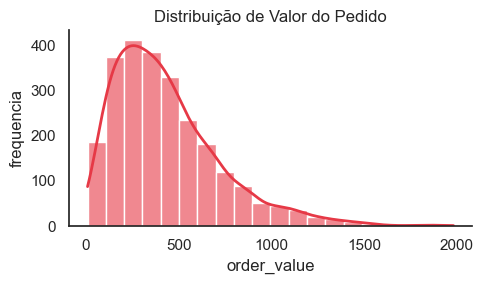

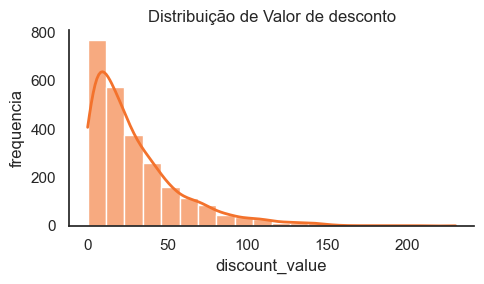

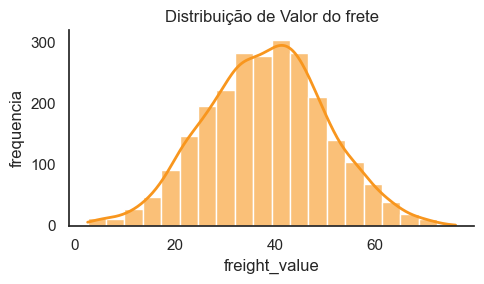

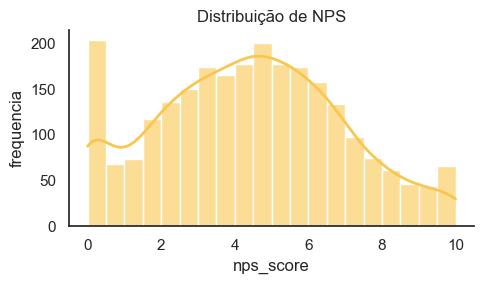

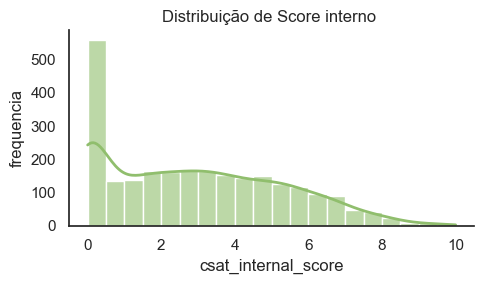

In [ ]:
#====================================================#
#   HISTOGRAMAS PARA IDENTIFICAÇÃO DE DISTRIBUIÇÃO
#====================================================#
# Permite analisar o comportamento e a distribuição dos valores, observando concentração, dispersão e possíveis assimetrias.

import seaborn as sns
import matplotlib.pyplot as plt

nomes_graficos = {
    "customer_age": "Idade do Cliente",
    "customer_tenure_months": "Tempo de Relacionamento (meses)",
    "order_value": "Valor do Pedido",
    "items_quantity": "Quantidade de Itens",
    "discount_value": "Valor de desconto",
    "payment_installments":"Número de parcelas",
    "delivery_time_days":"Tempo total de entrega",
    "delivery_delay_days": "Atraso na Entrega (dias)",
    "freight_value":"Valor do frete",
    "delivery_attempts": "Tentativas de Entrega",
    "customer_service_contacts": "Contatos com o Atendimento",
    "resolution_time_days": "Tempo de Resolução (dias)",
    "nps_score": "NPS",
    "complaints_count":"Número de reclamações registradas",
    "csat_internal_score":"Score interno "
}

#cores para os histogramas
cores = [
    "#E63946",  # 1. Vermelho
    "#F3722C",  # 2. Vermelho-laranja
    "#F8961E",  # 3. Laranja
    "#F9C74F",  # 4. Amarelo
    "#90BE6D",  # 5. Verde
    ]

for coluna, cor in zip(colunas_outliers_continuas, cores):
    
    plt.figure(figsize=(5,3))

    sns.histplot(
        df[coluna],
        bins=20,
        kde=True,
        color=cor,
        edgecolor=None,
        alpha=0.6,
        line_kws={
            "color":cor,
            "linewidth":2
        }
    )

    nome = nomes_graficos[coluna]
    plt.title(f"Distribuição de {nome}", fontsize=12)
    plt.xlabel(coluna)
    plt.ylabel("frequencia")

    sns.despine() #remove as bordas superior e direita do gráfico, deixando com uma aparência mais moderna.
    plt.tight_layout()
    plt.show()

    #deixei a linha que representa a densidade dos valores (kde) somente para as variáveis contínuas porque essa curva "suave" representa uma aproximação matemática passando por valores intermediários, ajudando na interpretação do histograma. 
    #Para as variáveis discretas, as barras são muito mais informativas, porque as variaveis são numeros inteiros.

In [ ]:
#====================================================#
#   HISTOGRAMAS PARA IDENTIFICAÇÃO DE DISTRIBUIÇÃO
#====================================================#
# Permite analisar o comportamento e a distribuição dos valores, observando concentração, dispersão e possíveis assimetrias.

import seaborn as sns
import matplotlib.pyplot as plt

nomes_graficos = {
    "customer_age": "Idade do Cliente",
    "customer_tenure_months": "Tempo de Relacionamento (meses)",
    "order_value": "Valor do Pedido",
    "items_quantity": "Quantidade de Itens",
    "discount_value": "Valor de desconto",
    "payment_installments":"Número de parcelas",
    "delivery_time_days":"Tempo total de entrega",
    "delivery_delay_days": "Atraso na Entrega (dias)",
    "freight_value":"Valor do frete",
    "delivery_attempts": "Tentativas de Entrega",
    "customer_service_contacts": "Contatos com o Atendimento",
    "resolution_time_days": "Tempo de Resolução (dias)",
    "nps_score": "NPS",
    "complaints_count":"Número de reclamações registradas",
    "csat_internal_score":"Score interno "
}

#cores para os histogramas
cores = [
    "#43AA8B",  # 6. Verde água
    "#4D908E",  # 7. Azul esverdeado
    "#277DA1",  # 8. Azul
    "#3867B3",  # 9. Azul médio
    "#3F37C9",  # 10. Azul escuro
    "#5E35B1",  # 11. Roxo
    "#7B2CBF",  # 12. Roxo claro
    "#9D4EDD",  # 13. Roxo/lilás
    "#D45087",  # 14. Rosa
    "#F15BB5"  # 15. Rosa claro
]

for coluna, cor in zip(colunas_outliers_discretas, cores):
    
    plt.figure(figsize=(5,3))

    sns.histplot(
        df[coluna],
        bins=20,
        kde=False,
        color=cor,
        edgecolor=None,
        alpha=0.6,
        line_kws={
            "color":cor,
            "linewidth":2
        }
    )

    nome = nomes_graficos[coluna]
    plt.title(f"Distribuição de {nome}", fontsize=12)
    plt.xlabel(coluna)
    plt.ylabel("frequencia")

    sns.despine() #remove as bordas superior e direita do gráfico, deixando com uma aparência mais moderna.
    plt.tight_layout()
    plt.show()

In [ ]:
#===============================================#
# BOXPLOT - IDENTIFICAÇÃO DE POSSIVEIS OUTLIERS
#===============================================#
# Permite identificar valores potencialmente discrepantes em relação ao intervalo interquartil da distribuição.
nomes_graficos = {
    "customer_age": "Idade do Cliente",
    "customer_tenure_months": "Tempo de Relacionamento (meses)",
    "order_value": "Valor do Pedido",
    "items_quantity": "Quantidade de Itens",
    "discount_value": "Valor de desconto",
    "payment_installments":"Número de parcelas",
    "delivery_time_days":"Tempo total de entrega",
    "delivery_delay_days": "Atraso na Entrega (dias)",
    "freight_value":"Valor do frete",
    "delivery_attempts": "Tentativas de Entrega",
    "customer_service_contacts": "Contatos com o Atendimento",
    "resolution_time_days": "Tempo de Resolução (dias)",
    "nps_score": "NPS",
    "complaints_count":"Número de reclamações registradas",
    "csat_internal_score":"Score interno "
}

#cores para os histogramas
cores = [
    "#E63946",  # 1. Vermelho
    "#F3722C",  # 2. Vermelho-laranja
    "#F8961E",  # 3. Laranja
    "#F9C74F",  # 4. Amarelo
    "#90BE6D",  # 5. Verde
    "#43AA8B",  # 6. Verde água
    "#4D908E",  # 7. Azul esverdeado
    "#277DA1",  # 8. Azul
    "#3867B3",  # 9. Azul médio
    "#3F37C9",  # 10. Azul escuro
    "#5E35B1",  # 11. Roxo
    "#7B2CBF",  # 12. Roxo claro
    "#9D4EDD",  # 13. Roxo/lilás
    "#D45087",  # 14. Rosa
    "#F15BB5"  # 15. Rosa claro
]

for coluna, cor in zip(nomes_graficos, cores):
    
    plt.figure(figsize=(5,3))

    sns.boxplot(
        data = df[coluna],
        color = cor        
    )

    nome = nomes_graficos[coluna]
    plt.title(f"Boxplot - {nome}", fontsize=12)
    plt.xlabel(coluna)
    plt.ylabel("frequencia")

    sns.despine() #remove as bordas superior e direita do gráfico, deixando com uma aparência mais moderna.
    plt.tight_layout()
    plt.show()

### Resultado e decisão

Os gráficos ajudam a identificar valores que merecem investigação, mas não
comprovam erro de registro.

Por isso:

- Valores extremos plausíveis serão mantidos;
- Regras críticas serão tratadas em uma etapa própria;
- Situações incomuns, mas possíveis, serão sinalizadas para a EDA.

Essa decisão evita remover experiências relevantes somente por serem raras. 

## 12. Tratamento das regras de qualidade e criação de variáveis

Nesta etapa serão aplicadas as decisões definidas para:

- Atraso maior que o tempo total de entrega;
- Desconto maior que o valor do pedido;
- Frete maior que o valor do pedido.

Depois serão criadas as variáveis:

- `had_delivery_delay`;
- `delivery_delay_ratio`;
- `freight_exceeds_order_value`;
- `had_customer_service_contact`;
- `had_complaint`;
- `age_group`;
- `tenure_group`;
- `nps_category`.

A base original continuará preservada em `df_original`.

### 12.1 Indicador de atraso

A variável `had_delivery_delay` foi criada para identificar se o pedido apresentou pelo
menos um dia de atraso na entrega.

A classificação utilizada foi:

- `0`: pedido sem atraso;
- `1`: pedido com atraso.

In [58]:
# Cria o indicador binário de atraso
df["had_delivery_delay"] = np.where(
    df["delivery_delay_days"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_atraso = pd.DataFrame({
    "quantidade": df["had_delivery_delay"].value_counts().sort_index(),
    "percentual": (
        df["had_delivery_delay"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_atraso

,quantidade,percentual
had_delivery_delay,,
0,277,11.08
1,2223,88.92


### 12.2 Indicador de contato com o atendimento

A variável `had_customer_service_contact` foi criada para identificar se o cliente
precisou entrar em contato com a equipe de atendimento.

A classificação utilizada foi:

- `0`: nenhum contato registrado;
- `1`: pelo menos um contato registrado.

In [59]:
# Cria o indicador binário de atendimento
df["had_customer_service_contact"] = np.where(
    df["customer_service_contacts"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_atendimento = pd.DataFrame({
    "quantidade": df["had_customer_service_contact"].value_counts().sort_index(),
    "percentual": (
        df["had_customer_service_contact"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_atendimento

,quantidade,percentual
had_customer_service_contact,,
0,554,22.16
1,1946,77.84


### 12.3 Indicador de reclamação

A variável `had_complaint` foi criada para identificar se existe pelo menos uma
reclamação registrada para o pedido.

A classificação utilizada foi:

- `0`: nenhuma reclamação registrada;
- `1`: uma ou mais reclamações registradas.

In [60]:
# Cria o indicador binário de reclamação
df["had_complaint"] = np.where(
    df["complaints_count"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_reclamacao = pd.DataFrame({
    "quantidade": df["had_complaint"].value_counts().sort_index(),
    "percentual": (
        df["had_complaint"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_reclamacao

,quantidade,percentual
had_complaint,,
0,23,0.92
1,2477,99.08


### Síntese dos indicadores operacionais

Os três indicadores criados apresentam alta concentração na categoria `1`:

| Indicador | Quantidade com ocorrência | Percentual |
|---|---:|---:|
| Pedido com atraso | 2.223 | 88,92% |
| Contato com atendimento | 1.946 | 77,84% |
| Pedido com reclamação | 2.477 | 99,08% |

Os resultados mostram que atraso, atendimento e reclamação são eventos frequentes
na base analisada.

Entretanto, as frequências não demonstram que esses fatores causam redução no
NPS. Elas apenas orientam as hipóteses que deverão ser investigadas na EDA.

Também será necessário considerar que os grupos são desbalanceados, principalmente
no indicador de reclamação. Por isso, as variáveis numéricas originais devem ser
preservadas:

- `delivery_delay_days`;
- `customer_service_contacts`;
- `complaints_count`.

Essas colunas permitem análises mais detalhadas do que os indicadores binários.

### 12.4 Regras críticas e registros para auditoria

Foram consideradas críticas as seguintes relações:

1. `delivery_delay_days > delivery_time_days`

   O atraso não deve superar o tempo total de entrega, considerando a definição
   apresentada no dicionário de dados.

2. `discount_value > order_value`

   O desconto não deve superar o valor total do pedido. Como a base não informa
   outro valor de referência para a compra, não existe informação suficiente para
   corrigir o registro com segurança.

A prática adotada será a **quarentena de dados**:

- Os registros não serão corrigidos por suposição;
- Eles serão retirados da base principal usada na EDA e na modelagem;
- Serão salvos separadamente com o motivo da inconsistência;
- A base original permanecerá preservada.

In [61]:
# Máscaras das regras críticas
regra_atraso = (
    df["delivery_delay_days"] > df["delivery_time_days"]
)

regra_desconto = (
    df["discount_value"] > df["order_value"]
)

# Um registro pode violar uma ou as duas regras
mascara_registro_critico = regra_atraso | regra_desconto

# Resumo antes do tratamento
resumo_regras_criticas = pd.DataFrame({
    "regra": [
        "Atraso maior que o tempo total de entrega",
        "Desconto maior que o valor do pedido",
        "Pelo menos uma regra crítica"
    ],
    "quantidade": [
        regra_atraso.sum(),
        regra_desconto.sum(),
        mascara_registro_critico.sum()
    ]
})

resumo_regras_criticas["percentual"] = (
    resumo_regras_criticas["quantidade"] / len(df) * 100
).round(2)

resumo_regras_criticas

,regra,quantidade,percentual
0,Atraso maior que o tempo total de entrega,121,4.84
1,Desconto maior que o valor do pedido,35,1.40
2,Pelo menos uma regra crítica,154,6.16


### 12.5 Identificação do motivo da inconsistência

Os registros críticos serão mantidos em uma base separada.

A coluna `inconsistency_reason` informa qual regra foi violada. Quando o mesmo
pedido viola as duas regras, os dois motivos são registrados.

Esse arquivo permite revisar os casos posteriormente sem misturá-los à base
principal.

In [62]:
# Seleciona os registros que violam pelo menos uma regra crítica
df_registros_rejeitados = df.loc[mascara_registro_critico].copy()

# Registra o motivo de cada inconsistência
df_registros_rejeitados["inconsistency_reason"] = ""

df_registros_rejeitados.loc[
    regra_atraso[mascara_registro_critico],
    "inconsistency_reason"
] = "atraso_maior_que_tempo_entrega"

df_registros_rejeitados.loc[
    regra_desconto[mascara_registro_critico],
    "inconsistency_reason"
] = (
    df_registros_rejeitados.loc[
        regra_desconto[mascara_registro_critico],
        "inconsistency_reason"
    ]
    .replace("", "desconto_maior_que_pedido")
    .replace(
        "atraso_maior_que_tempo_entrega",
        "atraso_maior_que_tempo_entrega; desconto_maior_que_pedido"
    )
)

print(f"Registros separados para auditoria: {len(df_registros_rejeitados)}")

df_registros_rejeitados[
    [
        "order_id",
        "order_value",
        "discount_value",
        "delivery_time_days",
        "delivery_delay_days",
        "inconsistency_reason"
    ]
].head(10)

Registros separados para auditoria: 154


,order_id,order_value,discount_value,delivery_time_days,delivery_delay_days,inconsistency_reason
5,50006,568.76,36.58,4,5,atraso_maior_que_tempo_entrega
6,50007,41.29,99.62,8,3,desconto_maior_que_pedido
18,50019,383.98,33.61,3,4,atraso_maior_que_tempo_entrega
41,50042,117.97,28.35,2,3,atraso_maior_que_tempo_entrega
46,50047,461.42,27.91,4,6,atraso_maior_que_tempo_entrega
57,50058,86.15,112.42,10,3,desconto_maior_que_pedido
58,50059,385.42,13.86,2,3,atraso_maior_que_tempo_entrega
61,50062,42.28,39.12,3,4,atraso_maior_que_tempo_entrega
71,50072,212.03,66.52,2,6,atraso_maior_que_tempo_entrega
113,50114,645.84,73.53,3,4,atraso_maior_que_tempo_entrega


In [63]:
# Mantém na base principal somente os registros aprovados
df = df.loc[~mascara_registro_critico].copy()

print(f"Registros da base original: {len(df_original)}")
print(f"Registros separados para auditoria: {len(df_registros_rejeitados)}")
print(f"Registros mantidos na base tratada: {len(df)}")
print(
    "Conferência do total: "
    f"{len(df_registros_rejeitados) + len(df)}"
)

Registros da base original: 2500
Registros separados para auditoria: 154
Registros mantidos na base tratada: 2346
Conferência do total: 2500


### 12.6 Frete maior que o valor do pedido

O frete maior que o valor do pedido é uma situação comercialmente incomum, mas não
é uma impossibilidade lógica.

Ela pode ocorrer em pedidos de baixo valor, rotas mais caras ou operações sem
subsídio de frete. Como a base não possui peso, distância, modalidade de entrega ou
regra de cobrança, não há evidência suficiente para classificar esses registros como
erro.

### Decisão adotada

Os registros serão mantidos e receberão a variável
`freight_exceeds_order_value`:

- `0`: frete menor ou igual ao valor do pedido;
- `1`: frete maior que o valor do pedido.

A variável permitirá verificar na EDA se essa relação está associada a notas menores
de NPS.

In [64]:
# Cria um indicador para pedidos cujo frete supera o valor do pedido
df["freight_exceeds_order_value"] = np.where(
    df["freight_value"] > df["order_value"],
    1,
    0
)

resumo_frete_pedido = pd.DataFrame({
    "quantidade": df["freight_exceeds_order_value"].value_counts(),
    "percentual": (
        df["freight_exceeds_order_value"].value_counts(normalize=True) * 100
    ).round(2)
})

resumo_frete_pedido

,quantidade,percentual
freight_exceeds_order_value,,
0,2339,99.7
1,7,0.3


### 12.7 Atraso percentual

Após a retirada dos registros que violavam a regra crítica de entrega, a variável
`delivery_delay_ratio` pode ser calculada de forma coerente:

`delivery_delay_days / delivery_time_days`

O resultado indica quanto do tempo total de entrega corresponde aos dias de atraso.

In [65]:
# Calcula o atraso proporcional ao tempo total de entrega
df["delivery_delay_ratio"] = (
    df["delivery_delay_days"] / df["delivery_time_days"]
)

# Confere se o resultado está entre 0 e 1
print(
    "Valores acima de 100%: ",
    (df["delivery_delay_ratio"] > 1).sum()
)

df["delivery_delay_ratio"].describe().round(2)

Valores acima de 100%:  0


count    2346.00
mean        0.31
std         0.26
min         0.00
25%         0.12
50%         0.25
75%         0.43
max         1.00
Name: delivery_delay_ratio, dtype: float64

### Resultado do tratamento

A base principal passa a conter apenas registros que atendem às duas regras
críticas.

O tratamento não tentou adivinhar ou substituir valores. Os registros separados
continuam disponíveis em um arquivo de auditoria.

O frete maior que o pedido foi mantido como uma característica observável. Essa
decisão preserva uma experiência potencialmente importante para explicar a
insatisfação, sem apresentar o caso como erro confirmado.

### 12.5 Faixa etária

A idade original será mantida como número. A nova coluna será usada apenas para
facilitar segmentações e comparações na EDA.

Os intervalos são uma decisão analítica deste projeto.

In [66]:
# Limites e rótulos das faixas etárias
limites_idade = [0, 24, 34, 44, 54, 64, np.inf]

rotulos_idade = [
    "Até 24 anos",
    "25 a 34 anos",
    "35 a 44 anos",
    "45 a 54 anos",
    "55 a 64 anos",
    "65 anos ou mais"
]

# Criação da faixa etária
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=limites_idade,
    labels=rotulos_idade,
    include_lowest=True
)

# Distribuição das faixas
df["age_group"].value_counts(sort=False, dropna=False)

age_group
Até 24 anos        326
25 a 34 anos       431
35 a 44 anos       469
45 a 54 anos       456
55 a 64 anos       440
65 anos ou mais    224
Name: count, dtype: int64

### Resultado observado

Todos os registros receberam uma faixa etária.

A maior faixa é **35 a 44 anos**, com 509 registros. A menor é **65 anos ou
mais**, com 238 registros. As demais faixas também possuem quantidade suficiente
para comparações exploratórias.

A coluna `customer_age` foi preservada para não perder a informação original.

### 12.6 Faixa de tempo de relacionamento

A variável `customer_tenure_months` será mantida. A nova coluna agrupa os clientes
por tempo de relacionamento para facilitar comparações na EDA.

Os intervalos também são uma decisão analítica deste projeto.

In [67]:
# Limites e rótulos das faixas de relacionamento
limites_tenure = [0, 12, 24, 48, 72, np.inf]

rotulos_tenure = [
    "Até 12 meses",
    "13 a 24 meses",
    "25 a 48 meses",
    "49 a 72 meses",
    "Mais de 72 meses"
]

# Criação da faixa de relacionamento
df["tenure_group"] = pd.cut(
    df["customer_tenure_months"],
    bins=limites_tenure,
    labels=rotulos_tenure,
    include_lowest=True
)

# Distribuição das faixas
df["tenure_group"].value_counts(sort=False, dropna=False)

tenure_group
Até 12 meses        227
13 a 24 meses       234
25 a 48 meses       441
49 a 72 meses       472
Mais de 72 meses    972
Name: count, dtype: int64

### Resultado observado

Todos os registros receberam uma faixa de relacionamento.

O maior grupo é **Mais de 72 meses**, com 1.041 registros. Isso mostra que uma
parte relevante da base possui relacionamento mais longo com a empresa.

A coluna numérica original foi mantida para análises que precisem do número exato
de meses.

## 13. Classificação do NPS

A base possui notas decimais entre 0 e 10. Para que todos os valores recebam uma
classe, adotamos intervalos contínuos:

- **Detrator:** nota menor ou igual a 6;
- **Neutro:** nota maior que 6 e menor ou igual a 8;
- **Promotor:** nota maior que 8 e menor ou igual a 10.

Essa é uma adaptação operacional da regra proposta no escopo. A nota original será
preservada.

In [68]:
# Conferência dos limites da variável antes da classificação
print(f"Menor nota de NPS: {df['nps_score'].min()}")
print(f"Maior nota de NPS: {df['nps_score'].max()}")

# Registros fora da escala esperada
df[~df["nps_score"].between(0, 10)]

Menor nota de NPS: 0.0
Maior nota de NPS: 10.0


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,repeat_purchase_30d,complaints_count,csat_internal_score,had_delivery_delay,had_customer_service_contact,had_complaint,freight_exceeds_order_value,delivery_delay_ratio,age_group,tenure_group


In [69]:
# Função de classificação do NPS
def classificar_nps(nota):
    if pd.isna(nota):
        return np.nan
    elif nota < 7:
        return "Detrator"
    elif nota < 9:
        return "Neutro"
    else:
        return "Promotor"

# Criação da classe
df["nps_category"] = df["nps_score"].apply(classificar_nps)

# Quantidade e percentual por classe
resumo_classes_nps = pd.DataFrame({
    "quantidade": df["nps_category"].value_counts(),
    "percentual": (
        df["nps_category"].value_counts(normalize=True) * 100
    ).round(2)
})

resumo_classes_nps

,quantidade,percentual
nps_category,,
Detrator,1964,83.72
Neutro,274,11.68
Promotor,108,4.60


In [70]:
# Conferência entre as notas e as classes atribuídas
pd.crosstab(
    df["nps_score"],
    df["nps_category"],
    margins=True
)

nps_category,Detrator,Neutro,Promotor,All
nps_score,,,,
0.0,135,0,0,135
0.1,8,0,0,8
0.2,11,0,0,11
0.3,8,0,0,8
0.4,13,0,0,13
...,...,...,...,...
9.7,0,0,3,3
9.8,0,0,3,3
9.9,0,0,2,2


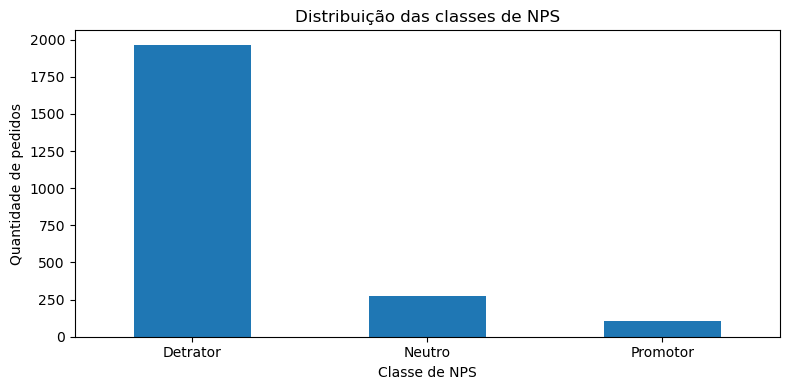

In [71]:
# Ordem das classes no gráfico
ordem_nps = ["Detrator", "Neutro", "Promotor"]

# Contagem organizada na ordem desejada
contagem_nps = (
    df["nps_category"]
    .value_counts()
    .reindex(ordem_nps)
)

# Gráfico de barras
plt.figure(figsize=(8, 4))
contagem_nps.plot(kind="bar")
plt.title("Distribuição das classes de NPS")
plt.xlabel("Classe de NPS")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Resultado observado

A classificação gerou:

- 1964 Detrator (**83.72**);
- 274 Neutro (**11.68%**);
- 108 Promotor (**4.60%**).

A base apresenta forte concentração na classe Detrator. Esse desbalanceamento
deverá ser considerado na etapa de modelagem, mas o tratamento específico pertence
ao notebook do item 4.

Para as próximas etapas:

- `nps_score` poderá ser utilizado como alvo de regressão;
- `nps_category` poderá ser utilizada como alvo de classificação.

## 14. Cuidado com o momento de coleta das variáveis

O objetivo do desafio é antecipar o NPS antes da aplicação da pesquisa.

Por isso, antes da modelagem, será necessário verificar quando cada variável foi
registrada. Uma informação disponível somente depois do NPS não poderá ser usada
como entrada do modelo.

Neste notebook, nenhuma coluna original será excluída por essa razão. A decisão
será tomada no notebook de modelagem, após a validação da linha do tempo dos
dados.

## 15. Validação das variáveis criadas

Antes da exportação, verificamos:

- Valores ausentes nas novas colunas;
- Quantidade de linhas e colunas;
- Duplicidades após as transformações.

In [72]:
# Variáveis criadas neste notebook
colunas_derivadas = [
    "had_delivery_delay",
    "delivery_delay_ratio",
    "freight_exceeds_order_value",
    "had_customer_service_contact",
    "had_complaint",
    "age_group",
    "tenure_group",
    "nps_category"
]

# Valores ausentes nas variáveis derivadas
df[colunas_derivadas].isnull().sum()

had_delivery_delay              0
delivery_delay_ratio            0
freight_exceeds_order_value     0
had_customer_service_contact    0
had_complaint                   0
age_group                       0
tenure_group                    0
nps_category                    0
dtype: int64

In [73]:
# Comparação entre a base original e a base tratada
resumo_final = pd.DataFrame({
    "indicador": [
        "Quantidade de linhas",
        "Quantidade de colunas",
        "Total de valores ausentes",
        "Linhas duplicadas"
    ],
    "base_original": [
        df_original.shape[0],
        df_original.shape[1],
        df_original.isnull().sum().sum(),
        df_original.duplicated().sum()
    ],
    "base_tratada": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

resumo_final

,indicador,base_original,base_tratada
0,Quantidade de linhas,2500,2346
1,Quantidade de colunas,19,27
2,Total de valores ausentes,0,0
3,Linhas duplicadas,0,0


### Resultado da validação

A base tratada possui:

- **2.346 registros aprovados**;
- **154 registros separados para auditoria**;
- Nenhum valor ausente nas variáveis derivadas;
- Nenhuma linha duplicada;
- Nenhum caso com atraso maior que o tempo total de entrega;
- Nenhum caso com desconto maior que o valor do pedido.

A soma da base tratada com a base de auditoria corresponde aos 2.500 registros
originais.

## 16. Organização das colunas

As colunas serão organizadas por assunto para facilitar a leitura do arquivo final:

1. Identificação;
2. Perfil do cliente;
3. Pedido;
4. Logística;
5. Atendimento;
6. Indicadores e satisfação.

As colunas originais serão mantidas na base tratada. As variáveis derivadas serão
posicionadas próximas às colunas que deram origem a elas.

In [74]:
# Ordem final das colunas
colunas_finais = [
    # Identificação
    "customer_id",
    "order_id",

    # Perfil do cliente
    "customer_age",
    "age_group",
    "customer_region",
    "customer_tenure_months",
    "tenure_group",

    # Pedido
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",

    # Logística
    "delivery_time_days",
    "delivery_delay_days",
    "had_delivery_delay",
    "delivery_delay_ratio",
    "freight_value",
    "freight_exceeds_order_value",
    "delivery_attempts",

    # Atendimento
    "customer_service_contacts",
    "had_customer_service_contact",
    "resolution_time_days",
    "complaints_count",
    "had_complaint",

    # Indicadores e satisfação
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_score",
    "nps_category"
]

# Reorganização da base
df = df[colunas_finais].copy()

# Conferência da estrutura final
df.head()

,customer_id,order_id,customer_age,age_group,customer_region,customer_tenure_months,tenure_group,order_value,items_quantity,discount_value,...,delivery_attempts,customer_service_contacts,had_customer_service_contact,resolution_time_days,complaints_count,had_complaint,repeat_purchase_30d,csat_internal_score,nps_score,nps_category
0,1,50001,63,55 a 64 anos,Nordeste,14,13 a 24 meses,139.73,4,39.35,...,3,0,0,4,3,1,0,6.5,6.9,Detrator
1,2,50002,20,Até 24 anos,Sul,1,Até 12 meses,458.95,2,9.51,...,3,0,0,10,3,1,0,0.0,2.4,Detrator
2,3,50003,46,45 a 54 anos,Nordeste,111,Mais de 72 meses,507.06,5,42.82,...,1,4,1,5,7,1,0,1.5,4.8,Detrator
3,4,50004,52,45 a 54 anos,Centro-Oeste,117,Mais de 72 meses,302.19,2,19.58,...,3,1,1,11,4,1,0,0.3,5.9,Detrator
4,5,50005,56,55 a 64 anos,Norte,50,49 a 72 meses,253.06,1,29.37,...,1,1,1,0,3,1,0,7.9,6.1,Detrator


## 17. Exportação das bases

Serão gerados dois arquivos:

1. `nps_tratado.csv`: base aprovada para EDA e modelagem;
2. `nps_registros_rejeitados.csv`: registros separados pelas regras críticas,
   incluindo o motivo da inconsistência.

A separação mantém a rastreabilidade do tratamento e evita perda definitiva de
informação.

In [75]:
# Pasta de saída
pasta_saida = "../data/processed"

# Cria a pasta se ela ainda não existir
os.makedirs(pasta_saida, exist_ok=True)

# Caminhos dos arquivos
caminho_saida = "../data/processed/nps_tratado.csv"
caminho_rejeitados = "../data/processed/nps_registros_rejeitados.csv"

# Exportação da base tratada
df.to_csv(
    caminho_saida,
    index=False,
    encoding="utf-8"
)

# Exportação dos registros separados para auditoria
df_registros_rejeitados.to_csv(
    caminho_rejeitados,
    index=False,
    encoding="utf-8"
)

print(f"Base tratada salva em: {caminho_saida}")
print(f"Registros para auditoria salvos em: {caminho_rejeitados}")
print(f"Dimensão final da base tratada: {df.shape}")

Base tratada salva em: ../data/processed/nps_tratado.csv
Registros para auditoria salvos em: ../data/processed/nps_registros_rejeitados.csv
Dimensão final da base tratada: (2346, 27)


In [76]:
# Releitura dos arquivos para confirmar a exportação
df_validacao = pd.read_csv(
    "../data/processed/nps_tratado.csv"
)

df_rejeitados_validacao = pd.read_csv(
    "../data/processed/nps_registros_rejeitados.csv"
)

print(f"Linhas da base tratada: {df_validacao.shape[0]}")
print(f"Colunas da base tratada: {df_validacao.shape[1]}")
print(
    "Registros no arquivo de auditoria: "
    f"{df_rejeitados_validacao.shape[0]}"
)
print(
    "Total conferido: "
    f"{df_validacao.shape[0] + df_rejeitados_validacao.shape[0]}"
)

df_validacao.head()

Linhas da base tratada: 2346
Colunas da base tratada: 27
Registros no arquivo de auditoria: 154
Total conferido: 2500


,customer_id,order_id,customer_age,age_group,customer_region,customer_tenure_months,tenure_group,order_value,items_quantity,discount_value,...,delivery_attempts,customer_service_contacts,had_customer_service_contact,resolution_time_days,complaints_count,had_complaint,repeat_purchase_30d,csat_internal_score,nps_score,nps_category
0,1,50001,63,55 a 64 anos,Nordeste,14,13 a 24 meses,139.73,4,39.35,...,3,0,0,4,3,1,0,6.5,6.9,Detrator
1,2,50002,20,Até 24 anos,Sul,1,Até 12 meses,458.95,2,9.51,...,3,0,0,10,3,1,0,0.0,2.4,Detrator
2,3,50003,46,45 a 54 anos,Nordeste,111,Mais de 72 meses,507.06,5,42.82,...,1,4,1,5,7,1,0,1.5,4.8,Detrator
3,4,50004,52,45 a 54 anos,Centro-Oeste,117,Mais de 72 meses,302.19,2,19.58,...,3,1,1,11,4,1,0,0.3,5.9,Detrator
4,5,50005,56,55 a 64 anos,Norte,50,49 a 72 meses,253.06,1,29.37,...,1,1,1,0,3,1,0,7.9,6.1,Detrator


### Resultado da exportação

Os arquivos foram salvos e relidos com sucesso:

- `data/processed/nps_tratado.csv`: **2.346 registros aprovados**;
- `data/processed/nps_registros_rejeitados.csv`: **154 registros para auditoria**.

A conferência dos dois arquivos retorna os 2.500 registros da base original.

# Conclusão executiva

A base recebida apresentou boa qualidade estrutural:

- Não havia valores ausentes;
- Não havia registros duplicados;
- Os tipos de dados estavam coerentes;
- As regiões já estavam padronizadas.

A análise de qualidade identificou três relações importantes.

## Registros separados da base principal

Foram aplicadas duas regras críticas:

- Atraso maior que o tempo total de entrega;
- Desconto maior que o valor do pedido.

Como não havia informação suficiente para corrigir esses valores, **154 registros**
foram separados para auditoria. Nenhum valor foi substituído por média, mediana ou
outra estimativa.

## Registros mantidos com sinalização

O frete maior que o valor do pedido foi mantido, pois é uma situação rara e
comercialmente desfavorável, mas possível. A variável `freight_exceeds_order_value` permitirá avaliar seu comportamento durante a EDA.

## Variáveis preparadas para as próximas etapas

Foram criadas variáveis para facilitar a análise:

- `had_delivery_delay`;
- `delivery_delay_ratio`;
- `freight_exceeds_order_value`;
- `had_customer_service_contact`;
- `had_complaint`;
- `age_group`;
- `tenure_group`;
- `nps_category`.

## Próxima etapa

Utilizar `data/processed/nps_tratado.csv` para investigar como características do
cliente, pedido, logística e atendimento se relacionam com `nps_score` e
`nps_category`.

O arquivo de auditoria deverá ser mantido no projeto para que os registros possam
ser revisados caso novas informações sobre as regras de origem estejam
disponíveis.